In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

class BurgersPINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 50), nn.Tanh(),
            nn.Linear(50, 50), nn.Tanh(),
            nn.Linear(50, 1)
        )
    def forward(self, xt):
        return self.net(xt)

print("Model ready!")

Model ready!


In [ ]:
nu = 0.1  # ν lớn để shock mềm

def burgers_residual(model, x, t):
    x = x.clone().requires_grad_(True)
    t = t.clone().requires_grad_(True)
    xt = torch.cat([x, t], dim=1)
    u = model(xt)
    u_t = torch.autograd.grad(u, t, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
    f = u_t + u * u_x - nu * u_xx  # Advection + diffusion
    return f

# IC: -sin(πx) at t=0
def ic_residual(model, x_ic):
    t_ic = torch.zeros_like(x_ic)
    xt_ic = torch.cat([x_ic, t_ic], dim=1)
    u_ic = model(xt_ic)
    u_exact_ic = -torch.sin(np.pi * x_ic)
    return u_ic - u_exact_ic

# BC: Periodic
def bc_residual(model, t_bc):
    x_left = -torch.ones_like(t_bc)
    x_right = torch.ones_like(t_bc)
    xt_left = torch.cat([x_left, t_bc], dim=1)
    xt_right = torch.cat([x_right, t_bc], dim=1)
    return model(xt_left) - model(xt_right)

print("Burgers ready (ν lớn)!")

Burgers ready (ν lớn)!


In [ ]:
model_pinn = BurgersPINN()
opt_pinn = torch.optim.Adam(model_pinn.parameters(), lr=0.001)

N = 50
x_col = torch.linspace(-1,1,N).unsqueeze(1)
t_col = torch.linspace(0,1,N).unsqueeze(1)
x_ic = torch.linspace(-1,1,N).unsqueeze(1)
t_bc = torch.linspace(0,1,N).unsqueeze(1)

for e in range(1000):
    opt_pinn.zero_grad()
    f = burgers_residual(model_pinn, x_col, t_col)
    ic = ic_residual(model_pinn, x_ic)
    bc = bc_residual(model_pinn, t_bc)
    loss = torch.mean(f**2) + torch.mean(ic**2) + torch.mean(bc**2)
    loss.backward()
    opt_pinn.step()
    if e % 200 == 0: print(f"PINN Epoch {e}, Loss: {loss.item():.4f}")

print("PINN done!")

PINN Epoch 0, Loss: 0.6122
PINN Epoch 200, Loss: 0.1125
PINN Epoch 400, Loss: 0.0074
PINN Epoch 600, Loss: 0.0023
PINN Epoch 800, Loss: 0.0012
PINN done!


In [ ]:
def region_sample(N=50):
    mean = torch.zeros(2)
    cov = torch.eye(2) * 0.1
    samples = torch.distributions.MultivariateNormal(mean, cov).sample((N,))
    samples = torch.clamp(samples, -1, 1)
    return samples[:,0].unsqueeze(1), samples[:,1].unsqueeze(1)

model_ropinn = BurgersPINN()
opt_ropinn = torch.optim.Adam(model_ropinn.parameters(), lr=0.001)

for e in range(1000):
    opt_ropinn.zero_grad()
    x_r, t_r = region_sample(N)
    f = burgers_residual(model_ropinn, x_r, t_r)
    ic = ic_residual(model_ropinn, x_ic)
    bc = bc_residual(model_ropinn, t_bc)
    loss = torch.mean(f**2) + torch.mean(ic**2) + torch.mean(bc**2)
    loss.backward()
    opt_ropinn.step()
    if e % 200 == 0: print(f"RoPINN Epoch {e}, Loss: {loss.item():.4f}")

print("RoPINN done!")

RoPINN Epoch 0, Loss: 0.5389
RoPINN Epoch 200, Loss: 0.0873
RoPINN Epoch 400, Loss: 0.0602
RoPINN Epoch 600, Loss: 0.0385
RoPINN Epoch 800, Loss: 0.0354
RoPINN done!


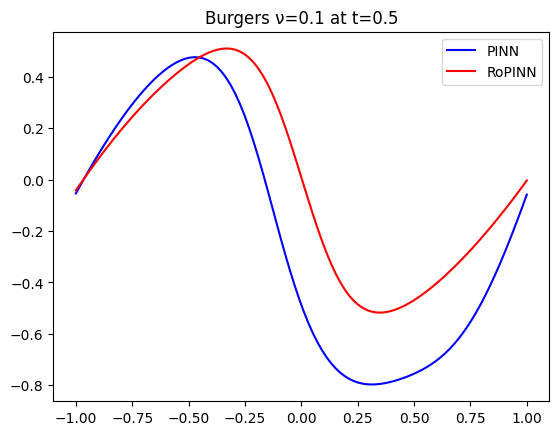

In [ ]:
x_test = torch.linspace(-1,1,100).unsqueeze(1)
t_test = 0.5 * torch.ones_like(x_test)
xt_test = torch.cat([x_test, t_test], dim=1)

u_pinn = model_pinn(xt_test).detach().numpy()
u_ropinn = model_ropinn(xt_test).detach().numpy()

plt.plot(x_test, u_pinn, 'b-', label='PINN')
plt.plot(x_test, u_ropinn, 'r-', label='RoPINN')
plt.title('Burgers ν=0.1 at t=0.5')
plt.legend()
plt.show()

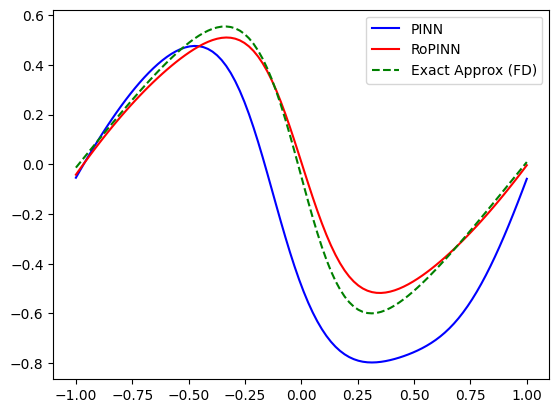

rMSE PINN: 0.24009229212107494
rMSE RoPINN: 0.04791546484426379


In [ ]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Proper Burgers finite difference solver
def burgers_fd(u, t, nx, dx, nu):
    un = u.copy()
    u[1:-1] = un[1:-1] - un[1:-1] * (dt/dx) * (un[1:-1] - un[0:-2]) + nu*(dt/dx**2) * (un[2:] - 2*un[1:-1] + un[0:-2])
    u[0] = u[-2]  # Periodic
    u[-1] = u[1]
    return u

# Setup
nx = 100
x = np.linspace(-1,1,nx)
dx = x[1]-x[0]
nt = 500
dt = 0.5 / nt  # To t=0.5
nu = 0.1
u0 = -np.sin(np.pi * x)

# Integrate (simple loop for stability)
u_exact = u0.copy()
for n in range(nt):
    u_exact = burgers_fd(u_exact, n*dt, nx, dx, nu)

# Plot comparison
plt.plot(x, u_pinn.flatten(), 'b-', label='PINN')
plt.plot(x, u_ropinn.flatten(), 'r-', label='RoPINN')
plt.plot(x, u_exact, 'g--', label='Exact Approx (FD)')
plt.legend()
plt.show()

rmse_pinn = np.sqrt(np.mean((u_pinn.flatten() - u_exact)**2))
rmse_ropinn = np.sqrt(np.mean((u_ropinn.flatten() - u_exact)**2))
print("rMSE PINN:", rmse_pinn)
print("rMSE RoPINN:", rmse_ropinn)